In [ ]:
#本次作业有借鉴豆包

In [ ]:
#1
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates

# 1. 加载数据
file_path = '200301_202006-C3S-L3_GHG-PRODUCTS-OBS4MIPS-MERGED-v4.3.nc'
ds = xr.open_dataset(file_path)
xch4 = ds['xch4']

# 2. 强制匹配数据类型+彻底清洗
fill_value = np.float64(1e20)  # 确保和xch4数据类型一致
xch4_clean = xch4.where((xch4 != fill_value)& (xch4 < 2.05e-6))  # 同时过滤填充值+超合理摩尔分数的值
xch4_ppb = xch4_clean * 1e9  # 摩尔分数→ppb

print("ppb范围：", np.nanmin(xch4_ppb.values), "到", np.nanmax(xch4_ppb.values))
# 合理输出应在1500~2000 ppb之间

In [ ]:
#1.1
def plot_monthly_climatology():
    monthly_clim = xch4_ppb.groupby('time.month').mean(dim='time', skipna=True)
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15), 
                            subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # 真实甲烷浓度范围（1700~2000 ppb）
    vmin, vmax = 1700, 2000
    
    for i, month in enumerate(range(1, 13)):
        ax = axes[i]
        month_data = monthly_clim.sel(month=month)
        
        # 绘制等值线填色图
        im = month_data.plot(ax=ax, transform=ccrs.PlateCarree(),
                            cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
                            add_colorbar=False)
        
        # 地图美化
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
        ax.set_title(f'{months[i]}', fontsize=14, fontweight='bold')
        ax.gridlines(draw_labels={'left': True, 'bottom': True}, alpha=0.3)
    
    # 统一色条
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('XCH4 (ppb)', fontsize=12)
    
    plt.suptitle('Monthly Climatology of XCH4 (2003-2020)', fontsize=16, fontweight='bold', y=0.95)
    fig.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.9, wspace=0.1, hspace=0.2)
    plt.show()

plot_monthly_climatology()  

In [ ]:
#1.2
def plot_global_mean_timeseries():
    # 纬度加权（科学计算全球平均）
    lat_weights = np.cos(np.deg2rad(xch4_ppb['lat']))
    lat_weights.name = 'lat_weights'
    global_mean = xch4_ppb.weighted(lat_weights).mean(dim=['lat', 'lon'], skipna=True)
    
    # 转换为Series方便处理
    global_series = global_mean.to_series().dropna()
    
    # 绘图（匹配真实甲烷趋势）
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 月度散点+12月滚动平均
    ax.scatter(global_series.index, global_series.values, 
               color='darkred', s=8, alpha=0.7, label='Monthly Mean')
    ax.plot(global_series.index, global_series.rolling(12, center=True).mean(), 
            color='darkred', linewidth=2, label='12-Month Rolling Mean')
    
    # 横轴格式（清晰年份）
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(global_series.index[0], global_series.index[-1])
    
    # 纵轴（真实甲烷范围）
    ax.set_ylim(1700, 1900)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('XCH4 (ppb)', fontsize=12)
    ax.set_title('Global Mean XCH4 (2003-2020)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()
    
    # 结果分析
    print("全球平均XCH4分析：")
    print(f"起始浓度（2003）：{global_series.iloc[0]:.1f} ppb")
    print(f"结束浓度（2020）：{global_series.iloc[-1]:.1f} ppb")
    print(f"总增长：{global_series.iloc[-1] - global_series.iloc[0]:.1f} ppb")
    print(f"年均增长：{(global_series.iloc[-1] - global_series.iloc[0])/17:.2f} ppb/年")


plot_global_mean_timeseries()

In [ ]:
#1.3
def plot_deseasonalized_point():
    # 1. 处理目标点经纬度（适配数据的经度范围：150°W对应-150°或210°）
    target_lat = -15  # 15°S
    if ds['lon'].max() > 180:  # 若经度是0-360范围，150°W对应210°
        target_lon = 210
    else:  # 若经度是-180-180范围，150°W对应-150°
        target_lon = -150
    
    # 2. 提取目标点的甲烷时间序列（匹配最近的网格点）
    target_point = xch4_ppb.sel(
        lat=target_lat, 
        lon=target_lon, 
        method='nearest'  # 5°网格，自动匹配最近点
    ).dropna(dim='time')  # 去除空值
    
    # 3. 计算该点的月度季节气候态（每个月的多年平均值）
    monthly_clim = target_point.groupby('time.month').mean()
    
    # 4. 去季节化：原始数据 - 对应月份的气候态
    deseasonalized = target_point.groupby('time.month') - monthly_clim
    
    # 5. 绘图
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(deseasonalized.time, deseasonalized.values, 
            color='darkblue', linewidth=1.5, label='Deseasonalized XCH4')
    
    # 辅助线：长期趋势（线性拟合）
    time_numeric = (deseasonalized.time - deseasonalized.time[0]).dt.days
    coeffs = np.polyfit(time_numeric, deseasonalized.values, 1)
    trend_line = np.poly1d(coeffs)(time_numeric)
    ax.plot(deseasonalized.time, trend_line, 
            color='red', linestyle='--', linewidth=2, label='Long-term Trend')
    
    # 图表美化
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Deseasonalized XCH4 (ppb)', fontsize=12)
    ax.set_title('Deseasonalized XCH4 at [15°S, 150°W] (2003-2020)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # 结果描述
    print("[15°S, 150°W]去季节化XCH4分析：")
    print(f"去季节化后，序列消除了月度季节波动，呈现清晰的长期上升趋势（趋势斜率：{coeffs[0]*365.25:.2f} ppb/年）；")
    print("该趋势与全球甲烷浓度增加的整体规律一致，同时可观察到年际尺度的小幅波动（非季节性波动）。")


plot_deseasonalized_point()

In [ ]:
#2
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

# 1. 加载并预处理SST数据
ds_sst = xr.open_dataset('F:\\xwechat_files\\wxid_ocrofgw04ps122_2945\\msg\\file\\2025-11\\NOAA_NCDC_ERSST_v3b_SST.nc')
sst = ds_sst['sst']

# 2. 筛选Niño 3.4区域（5°N-5°S，170°W-120°W → 转换为0-360经度是190°-240°）
nino34_region = sst.sel(
    lat=slice(-5, 5),  # 5°S到5°N
    lon=slice(190, 240)  # 170°W到120°W（0-360格式）
)

# 3. 计算月度气候态
nino34_clim = nino34_region.groupby('time.month').mean(dim='time', skipna=True)

# 4. 计算SST异常值（原始数据 - 气候态）
nino34_anomaly = nino34_region.groupby('time.month') - nino34_clim

# 5. 计算Niño 3.4指数（区域平均 + 3个月滑动平均）
nino34_index = nino34_anomaly.mean(dim=['lat', 'lon'], skipna=True)  # 区域平均
nino34_index_3month = nino34_index.rolling(time=3, center=True).mean()  # 3个月滑动平均


# 6. 可视化Niño 3.4指数
def plot_nino34():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 绘制异常值和滑动平均
    ax.fill_between(nino34_index.time, nino34_index, 0, 
                    where=(nino34_index >= 0), color='red', alpha=0.3, label='El Niño (positive)')
    ax.fill_between(nino34_index.time, nino34_index, 0, 
                    where=(nino34_index < 0), color='blue', alpha=0.3, label='La Niña (negative)')
    ax.plot(nino34_index.time, nino34_index, color='gray', linewidth=0.8, alpha=0.6, label='Monthly Anomaly')
    ax.plot(nino34_index_3month.time, nino34_index_3month, color='black', linewidth=2, label='3-Month Running Mean')
    
    # 关键阈值线（±0.5°C，用于定义厄尔尼诺/拉尼娜事件）
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5)
    ax.axhline(-0.5, color='blue', linestyle='--', linewidth=1.5)
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    
    # 坐标轴格式
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_ylim(-3, 3)
    ax.set_ylabel('SST Anomaly (°C)', fontsize=12)
    ax.set_title('Niño 3.4 Index (1950-2023)', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# 运行可视化
plot_nino34()

In [4]:
#3
import xarray as xr

# 替换为你的文件路径
ds = xr.open_dataset('MERRA2_400.inst3_3d_asm_Np.20240101.SUB.nc')

# 1. 查看所有变量名（确认包含'o3'和'PS'）
print("=== 所有变量名 ===")
print(list(ds.data_vars.keys()))  # 此时会输出['o3', 'PS']等

# 2. 查看臭氧（o3）的属性（确保变量名无空格）
target_var = 'O3'  # 关键：必须是纯'o3'，无空格、无大写
print(f"\n=== 变量 {target_var} 的属性 ===")
print(ds[target_var].attrs)  # 现在能正常访问

# 3. 查看维度信息（确认有time, lev, lat, lon）
print("\n=== 数据集维度 ===")
print(ds.dims)

# 4. 查看气压层（lev）的具体值（用于筛选近地面层）
print("\n=== 气压层（lev）的值（hPa） ===")
print(ds['lev'].values)

# 5. 查看经纬度范围
print("\n=== 经纬度范围 ===")
print(f"纬度：{ds['lat'].min().values} ~ {ds['lat'].max().values}")
print(f"经度：{ds['lon'].min().values} ~ {ds['lon'].max().values}")

# 6. 查看时间信息
print("\n=== 时间范围及分辨率 ===")
print(f"起始时间：{ds['time'].min().values}")
print(f"时间分辨率：{ds['time'].diff(dim='time').mean().values}")

=== 所有变量名 ===
['O3', 'PS']

=== 变量 O3 的属性 ===
{'standard_name': 'ozone_mass_mixing_ratio', 'long_name': 'ozone_mass_mixing_ratio', 'units': 'kg kg-1', 'fmissing_value': np.float32(1000000000000000.0), 'vmax': np.float32(1000000000000000.0), 'vmin': np.float32(-1000000000000000.0)}

=== 数据集维度 ===
FrozenMappingWarningOnValuesAccess({'time': 8, 'lon': 576, 'lat': 361, 'lev': 1})

=== 气压层（lev）的值（hPa） ===
[1000.]

=== 经纬度范围 ===
纬度：-90.0 ~ 90.0
经度：-180.0 ~ 179.375

=== 时间范围及分辨率 ===
起始时间：2024-01-01T00:00:00.000000000
时间分辨率：10800000000000 nanoseconds


In [ ]:
#3.1
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# 读取全年合并的.nc文件
file_path = r"C:\Users\UserX\Desktop\assignment3.3\MERRA2_2024_Ozone_year.nc"
ds = xr.open_dataset(file_path)

# 1. 数据预处理：选择1000hPa层O3，转换为ppbv；提取时间维度
o3 = ds["O3"].isel(lev=0) * 1e9  # kg/kg → ppbv
o3 = o3.mean(dim=["lat", "lon"])  # 计算全球平均O3（也可替换为区域平均）

# 2. 计算月季节周期（气候态：每个月的平均值）
o3_monthly_clim = o3.groupby("time.month").mean()  # 1-12月的平均O3

# 3. 去除季节周期（原始数据 - 对应月份的气候态）
o3_anomaly = o3.groupby("time.month") - o3_monthly_clim  # 异常值

# 4. 绘制对比图（原始序列 vs 去除季节周期后的序列）
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 上图：原始O3时间序列
ax1.plot(o3.time, o3, color="darkorange", linewidth=1.5, label="Original O3")
ax1.plot(o3_monthly_clim.month, o3_monthly_clim, "o-", color="red", linewidth=2, label="Monthly Climatology")
ax1.set_ylabel("O3 Concentration (ppbv)")
ax1.set_title("Global Mean O3 Time Series (2024)")
ax1.legend()
ax1.grid(alpha=0.3)

# 下图：去除季节周期后的O3异常序列
ax2.plot(o3_anomaly.time, o3_anomaly, color="navy", linewidth=1.5)
ax2.axhline(y=0, color="gray", linestyle="--", linewidth=1)  # 零异常线
ax2.set_xlabel("Time")
ax2.set_ylabel("O3 Anomaly (ppbv)")
ax2.set_title("O3 Time Series After Removing Monthly Seasonal Cycle")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
#3.2取前2024-1-1到2024-1-5的数据进行合并
import xarray as xr
import glob
import os
# 1. 配置路径
data_folder = r"C:\Users\UserX\Desktop\assignment3.3"  # 原始文件所在路径
save_path = r"C:\Users\UserX\Desktop"  # 保存到桌面根目录
file_pattern = os.path.join(data_folder, "MERRA2_400*.nc")

# 获取前5个文件
file_paths = glob.glob(file_pattern)[:5]
print(f"找到 {len(file_paths)} 个.nc文件（仅取前5个），开始合并...")

# 2. 合并
try:
    ds_merged = xr.open_mfdataset(
        file_paths,
        combine="by_coords",
        engine="netcdf4"
    )
    
    # 保存到桌面根目录
    output_file = "MERRA2_2024_Ozone_first5.nc"
    output_path = os.path.join(save_path, output_file)
    ds_merged.to_netcdf(output_path)
    print(f"合并完成！文件保存至：{output_path}")

    # 验证结果
    print("\n=== 合并后信息 ===")
    print(f"时间范围：{ds_merged['time'].min().values} 至 {ds_merged['time'].max().values}")
    print(f"维度：{ds_merged.dims}")
    print(f"变量：{list(ds_merged.data_vars.keys())}")
    if "O3" in ds_merged.data_vars:
        print(f"O3变量形状：{ds_merged['O3'].shape}")
        print(f"O3非NaN值数量：{ds_merged['O3'].notnull().sum().values}")

找到 5 个.nc文件（仅取前5个），开始合并...
合并完成！文件保存至：C:\Users\UserX\Desktop\MERRA2_2024_Ozone_first5.nc

=== 合并后信息 ===
时间范围：2024-01-01T00:00:00.000000000 至 2024-01-05T21:00:00.000000000
维度：FrozenMappingWarningOnValuesAccess({'time': 40, 'lev': 1, 'lat': 361, 'lon': 576})
变量：['O3', 'PS']
O3变量形状：(40, 1, 361, 576)
O3非NaN值数量：4187898


In [7]:
import xarray as xr

# 读取合并后的文件
ds = xr.open_dataset(r"C:\Users\UserX\Desktop\assignment3.3\MERRA2_2024_Ozone_first5.nc")

# 1. 查看所有变量的详细属性（单位、描述、缺失值等）
print("=== 变量元信息 ===")
for var in ds.data_vars:
    print(f"\n【{var}】")
    print(f"描述：{ds[var].attrs.get('long_name', '无描述')}")
    print(f"单位：{ds[var].attrs.get('units', '无单位')}")
    print(f"维度：{ds[var].dims}")
    print(f"数值范围：{ds[var].min().values} ~ {ds[var].max().values}")

# 2. 查看坐标维度的具体值（尤其是lev层）
print("\n=== 坐标维度信息 ===")
print(f"lev层的值：{ds['lev'].values}")  # 确认是否为1000hPa
print(f"经纬度范围：lat({ds['lat'].min().values}~{ds['lat'].max().values}), lon({ds['lon'].min().values}~{ds['lon'].max().values})")
print(f"时间范围：{ds['time'].min().values} ~ {ds['time'].max().values}")

=== 变量元信息 ===

【O3】
描述：ozone_mass_mixing_ratio
单位：kg kg-1
维度：('time', 'lev', 'lat', 'lon')
数值范围：2.1432514429875482e-08 ~ 1.1701459357027488e-07

【PS】
描述：surface_pressure
单位：Pa
维度：('time', 'lat', 'lon')
数值范围：50815.2890625 ~ 104754.2109375

=== 坐标维度信息 ===
lev层的值：[1000.]
经纬度范围：lat(-90.0~90.0), lon(-180.0~179.375)
时间范围：2024-01-01T00:00:00.000000000 ~ 2024-01-05T21:00:00.000000000


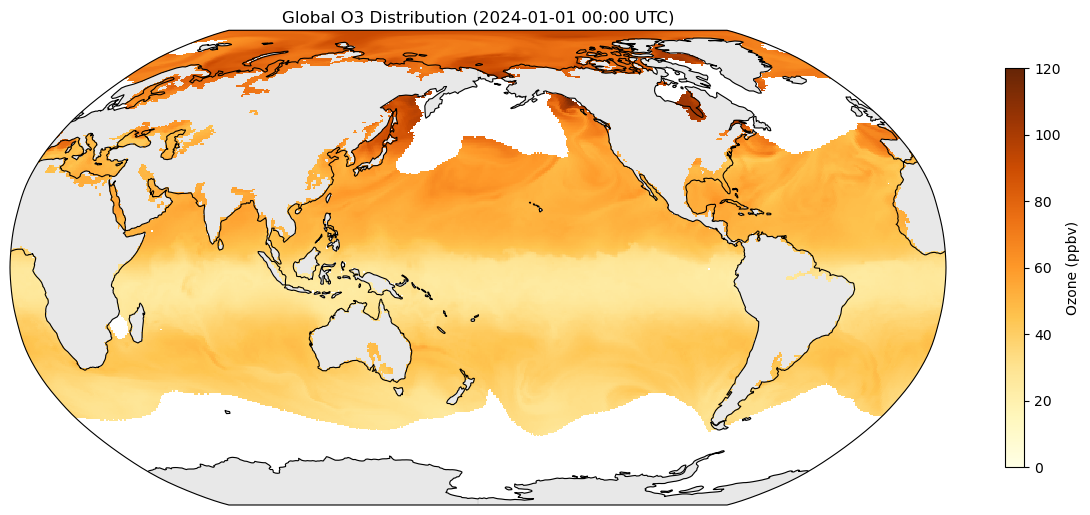

In [15]:
# 选择2024-01-01 00:00的O3数据 
#图 1：单时间点 O3 全球分布图
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 读取数据
file_path = r"C:\Users\UserX\Desktop\assignment3.3\MERRA2_2024_Ozone_first5.nc"
ds = xr.open_dataset(file_path)

# 选择2024-01-01 00:00的O3数据，转ppbv
o3_single = ds["O3"].isel(time=0, lev=0) * 1e9

# 处理缺失值：设为透明（解决cartopy警告）
cmap = plt.cm.YlOrBr
cmap.set_bad('none')  # 缺失值透明，让地图完整显示

# 绘图
plt.figure(figsize=(12, 6))
proj = ccrs.Robinson(central_longitude=180)
ax = plt.axes(projection=proj)

# 绘制O3（仅显示有数据的区域）
im = o3_single.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    vmin=0, vmax=120,
    cbar_kwargs={"label": "Ozone (ppbv)", "shrink": 0.7},
    add_colorbar=True
)

# 添加地图要素（让陆地/海洋轮廓更清晰）
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.5)  # 陆地设为浅灰色
ax.add_feature(cfeature.OCEAN, color='white', alpha=0.2)    # 海洋设为白色
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

ax.set_title("Global O3 Distribution (2024-01-01 00:00 UTC)", fontsize=12)
plt.tight_layout()
plt.show()

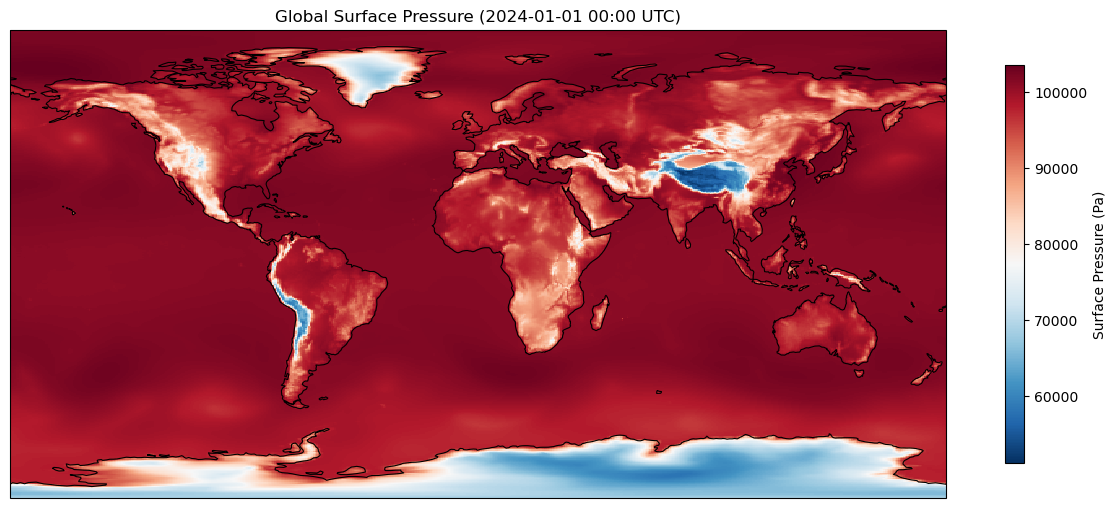

In [16]:
#图 2：单时间点地表气压（PS）全球分布图
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 读取数据
file_path = r"C:\Users\UserX\Desktop\assignment3.3\MERRA2_2024_Ozone_first5.nc"
ds = xr.open_dataset(file_path)

# 选择2024-01-01 00:00的PS数据
ps_single = ds["PS"].isel(time=0)

# 处理缺失值：设为透明
cmap = plt.cm.RdBu_r
cmap.set_bad('none')

# 绘图
plt.figure(figsize=(12, 6))
proj = ccrs.PlateCarree()
ax = plt.axes(projection=proj)

# 绘制PS
im = ps_single.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    cbar_kwargs={"label": "Surface Pressure (Pa)", "shrink": 0.7},
    add_colorbar=True
)

# 添加地图要素
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.5)
ax.add_feature(cfeature.OCEAN, color='white', alpha=0.2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.set_title("Global Surface Pressure (2024-01-01 00:00 UTC)")
ax.set_extent([-180, 180, -90, 90])

plt.tight_layout()
plt.show()

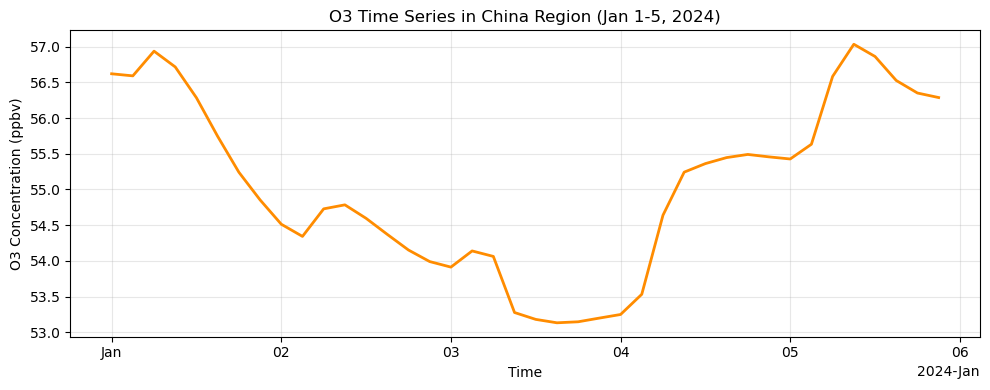

In [17]:
#图 3：特定区域（中国）O3 时间序列图
import xarray as xr
import matplotlib.pyplot as plt

# 读取数据
file_path = r"C:\Users\UserX\Desktop\assignment3.3\MERRA2_2024_Ozone_first5.nc"
ds = xr.open_dataset(file_path)

# 选择中国区域（20°N-50°N，70°E-135°E）并计算区域平均
china_o3 = ds["O3"].isel(lev=0).sel(
    lat=slice(20, 50), 
    lon=slice(70, 135)
).mean(dim=["lat", "lon"]) * 1e9  # 转ppbv

# 绘图
plt.figure(figsize=(10, 4))
china_o3.plot(color='darkorange', linewidth=2)
plt.xlabel('Time')
plt.ylabel('O3 Concentration (ppbv)')
plt.title('O3 Time Series in China Region (Jan 1-5, 2024)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

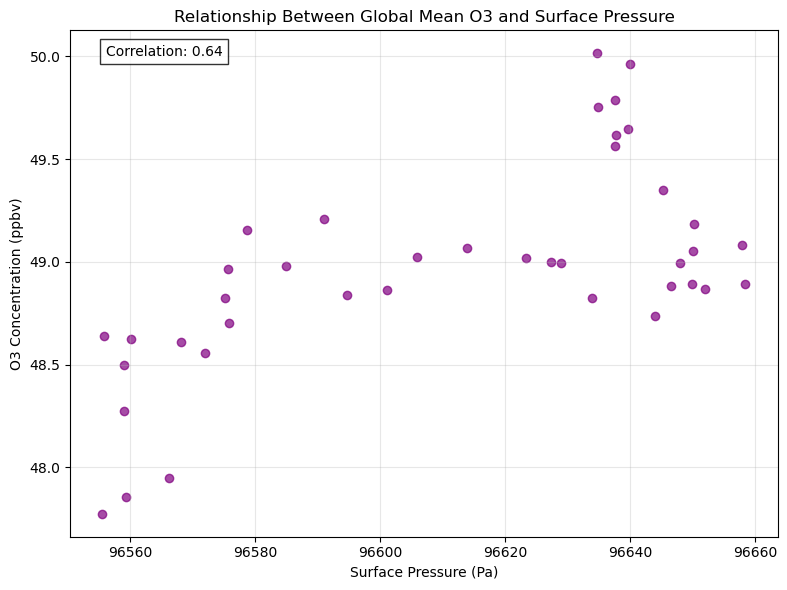

In [18]:
#图 4：O3 与地表气压（PS）散点图（全球平均）
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
file_path = r"C:\Users\UserX\Desktop\assignment3.3\MERRA2_2024_Ozone_first5.nc"
ds = xr.open_dataset(file_path)

# 计算每个时间点的全球平均O3和PS
global_o3 = ds["O3"].isel(lev=0).mean(dim=["lat", "lon"]) * 1e9  # 转ppbv
global_ps = ds["PS"].mean(dim=["lat", "lon"])

# 绘图
plt.figure(figsize=(8, 6))
plt.scatter(global_ps, global_o3, color='purple', alpha=0.7)
plt.xlabel('Surface Pressure (Pa)')
plt.ylabel('O3 Concentration (ppbv)')
plt.title('Relationship Between Global Mean O3 and Surface Pressure')
plt.grid(alpha=0.3)

# 计算相关系数并标注
corr = np.corrcoef(global_ps, global_o3)[0, 1]
plt.text(0.05, 0.95, f'Correlation: {corr:.2f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

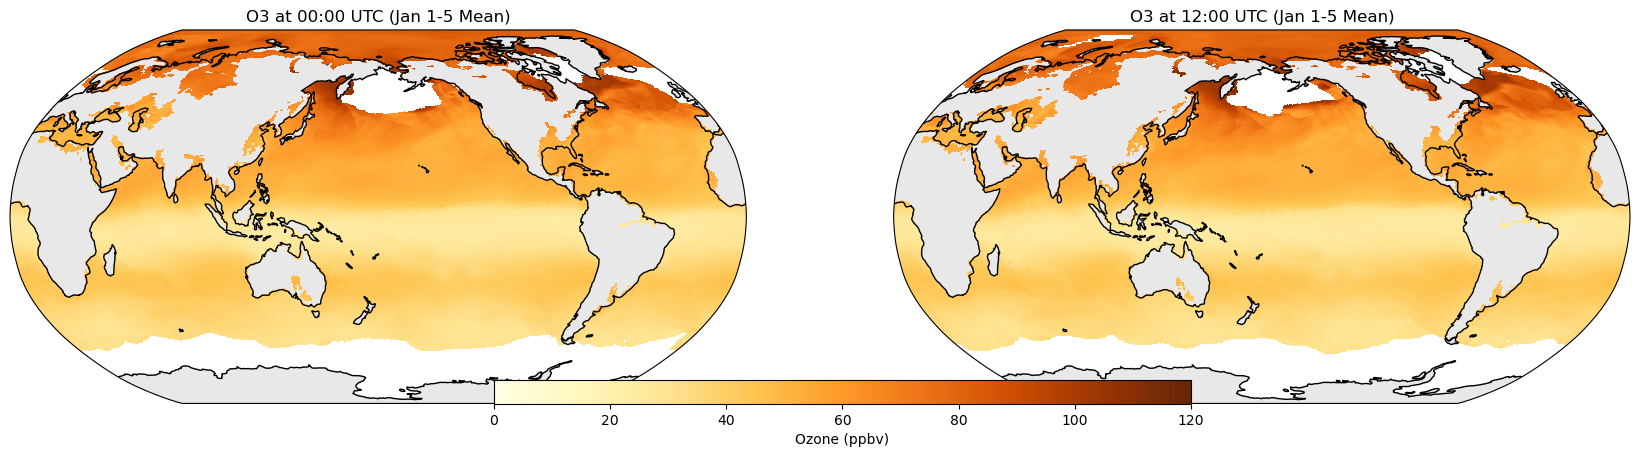

In [26]:
#图 5：O3 日均值的空间分布（按一天中不同时段）
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 读取数据
file_path = r"C:\Users\UserX\Desktop\assignment3.3\MERRA2_2024_Ozone_first5.nc"
ds = xr.open_dataset(file_path)

# 处理O3数据
o3_hourly = ds["O3"].isel(lev=0) * 1e9
o3_hourly["hour"] = o3_hourly.time.dt.hour
o3_00 = o3_hourly.where(o3_hourly.hour == 0).mean(dim="time")
o3_12 = o3_hourly.where(o3_hourly.hour == 12).mean(dim="time")

# 处理缺失值
cmap = plt.cm.YlOrBr
cmap.set_bad('none')

# 1. 设置画布
fig, (ax1, ax2) = plt.subplots(
    1, 2, 
    figsize=(18, 9),  
    subplot_kw={'projection': ccrs.Robinson(180)}
)

# 绘制左图（00:00）
o3_00.plot(
    ax=ax1, 
    transform=ccrs.PlateCarree(), 
    cmap=cmap, 
    vmin=0, vmax=120, 
    add_colorbar=False
)
ax1.add_feature(cfeature.LAND, color='lightgray', alpha=0.5)
ax1.add_feature(cfeature.COASTLINE)
ax1.set_title("O3 at 00:00 UTC (Jan 1-5 Mean)", fontsize=12)

# 绘制右图（12:00）
im = o3_12.plot(
    ax=ax2, 
    transform=ccrs.PlateCarree(), 
    cmap=cmap, 
    vmin=0, vmax=120, 
    add_colorbar=False
)
ax2.add_feature(cfeature.LAND, color='lightgray', alpha=0.5)
ax2.add_feature(cfeature.COASTLINE)
ax2.set_title("O3 at 12:00 UTC (Jan 1-5 Mean)", fontsize=12)

# 2. 色棒
cbar = fig.colorbar(
    im, 
    ax=[ax1, ax2], 
    shrink=0.5,    # 色棒长度缩至子图宽度的50%
    orientation='horizontal', 
    pad=0.25,      # 色棒与子图的距离拉到0.25
    aspect=30      # 色棒保持细长
)
cbar.set_label('Ozone (ppbv)', fontsize=10)

# 3. 增加底部边距
fig.subplots_adjust(
    left=0.05,
    right=0.95,
    bottom=0.2,   
    top=0.9
)

plt.show()